In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, precision_score, classification_report
from sklearn.metrics import ConfusionMatrixDisplay

In [2]:
df = pd.read_csv("employee_turnover.csv")

In [3]:
# Collection of basic info

df.info()
df.shape
df.head()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1350 entries, 0 to 1349
Data columns (total 16 columns):
 #   Column                                   Non-Null Count  Dtype  
---  ------                                   --------------  -----  
 0   Job_Satisfaction                         1350 non-null   float64
 1   Performance_Rating                       1350 non-null   float64
 2   Years_At_Company                         1350 non-null   float64
 3   Work_Life_Balance                        1350 non-null   float64
 4   Distance_From_Home                       1350 non-null   float64
 5   Monthly_Income                           1350 non-null   float64
 6   Education_Level                          1350 non-null   float64
 7   Age                                      1350 non-null   float64
 8   Num_Companies_Worked                     1350 non-null   float64
 9   Employee_Role                            1350 non-null   float64
 10  Annual_Bonus                             1350 no

,Job_Satisfaction,Performance_Rating,Years_At_Company,Work_Life_Balance,Distance_From_Home,Monthly_Income,Education_Level,Age,Num_Companies_Worked,Employee_Role,Annual_Bonus,Training_Hours,Department,Annual_Bonus_Squared,Annual_Bonus_Training_Hours_Interaction,Employee_Turnover
0,0.562326,0.141129,0.123989,0.347583,0.330353,0.328853,0.600933,0.315990,0.768736,0.090671,0.324786,0.669193,0.602932,0.105486,0.217344,0
1,0.017041,0.559047,0.511203,0.793908,0.423550,0.553450,0.742009,0.897146,0.380035,0.601633,0.694611,0.043271,0.800761,0.482484,0.030056,0
2,0.774699,0.604371,0.798174,0.260500,0.804034,0.131800,0.775178,0.830947,0.218726,0.972936,0.153476,0.701336,0.705275,0.023555,0.107638,1
3,0.628174,0.385249,0.230104,0.516809,0.272248,0.589249,0.482409,0.090507,0.402746,0.132842,0.305973,0.549688,0.600531,0.093620,0.168190,0
4,0.799183,0.199967,0.839029,0.247927,0.341934,0.076818,0.055356,0.680860,0.923341,0.493017,0.844094,0.793751,0.664679,0.712494,0.670000,0


In [4]:
# Check for missing values

missing = pd.DataFrame({
    "missing_count": df.isnull().sum(),
    "missing_%": (df.isnull().sum())*100

})

missing_val = missing[missing["missing_count"]>0]
print("No missing values found!") if missing_val.empty else missing_val

No missing values found!


In [5]:
# Check for duplicate values

duplicates = df.duplicated().sum()

if duplicates > 0:
    duplicate_rows = df[df.duplicated()]
    print(duplicate_rows)
    df = df.drop_duplicates()
    df.shape # New shape achieved has 450 rows and 16 cols
else:
    print("No duplicates found!")

      Job_Satisfaction  Performance_Rating  Years_At_Company  \
450           0.472283            0.470477          0.086397   
451           0.437575            0.661254          0.292472   
454           0.269063            0.189804          0.373346   
458           0.706676            0.029110          0.083787   
463           0.118491            0.697574          0.993262   
...                ...                 ...               ...   
1337          0.891459            0.186654          0.895959   
1340          0.339690            0.721738          0.140120   
1342          0.973103            0.224039          0.278460   
1346          0.396906            0.182952          0.877941   
1349          0.496702            0.523527          0.779612   

      Work_Life_Balance  Distance_From_Home  Monthly_Income  Education_Level  \
450            0.173957            0.278577        0.587710         0.996112   
451            0.503861            0.371370        0.366578         0.1

In [6]:
# Check for data inconsistency
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 900 entries, 0 to 1348
Data columns (total 16 columns):
 #   Column                                   Non-Null Count  Dtype  
---  ------                                   --------------  -----  
 0   Job_Satisfaction                         900 non-null    float64
 1   Performance_Rating                       900 non-null    float64
 2   Years_At_Company                         900 non-null    float64
 3   Work_Life_Balance                        900 non-null    float64
 4   Distance_From_Home                       900 non-null    float64
 5   Monthly_Income                           900 non-null    float64
 6   Education_Level                          900 non-null    float64
 7   Age                                      900 non-null    float64
 8   Num_Companies_Worked                     900 non-null    float64
 9   Employee_Role                            900 non-null    float64
 10  Annual_Bonus                             900 non-null 

In [7]:
# Fix column names and column data

df.columns = df.columns.str.strip() 

In [8]:
# Train_Test_Split

X = df.drop("Employee_Turnover", axis = 1)
y = df["Employee_Turnover"]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

In [9]:
# Baseline logistic regression

model = LogisticRegression(max_iter=200)
model.fit(X_train, y_train)

,penalty,'l2'
,dual,False
,tol,0.0001
,C,1.0
,fit_intercept,True
,intercept_scaling,1
,class_weight,None
,random_state,None
,solver,'lbfgs'
,max_iter,200
,multi_class,'deprecated'


In [10]:
# Prediction Values

y_pred = model.predict(X_test)

In [11]:
# Evaluation Metrics

acc_score = accuracy_score(y_test,y_pred)
precision = precision_score(y_test,y_pred)

print("Accuracy:", acc_score)
print("Precision:", precision)

Accuracy: 0.8388888888888889
Precision: 0.9090909090909091


In [12]:
# Optimising the model using regularisation

In [13]:
# L1 Regularization (Lasso)
lasso = LogisticRegression(penalty='l1', solver='liblinear', C=0.5)
lasso.fit(X_train, y_train)

,penalty,'l1'
,dual,False
,tol,0.0001
,C,0.5
,fit_intercept,True
,intercept_scaling,1
,class_weight,None
,random_state,None
,solver,'liblinear'
,max_iter,100
,multi_class,'deprecated'


In [14]:
# Prediction Values

y_pred = lasso.predict(X_test)

In [15]:
# Evaluation Metrics

acc_score = accuracy_score(y_test,y_pred)
precision = precision_score(y_test,y_pred)

print("Accuracy:", acc_score)
print("Precision:", precision)

Accuracy: 0.85
Precision: 0.9113924050632911


In [16]:
# L2 Regularisation (Ridge)
ridge = LogisticRegression(penalty='l2', C=1, max_iter=200)
ridge.fit(X_train, y_train)

,penalty,'l2'
,dual,False
,tol,0.0001
,C,1
,fit_intercept,True
,intercept_scaling,1
,class_weight,None
,random_state,None
,solver,'lbfgs'
,max_iter,200
,multi_class,'deprecated'


In [17]:
# Prediction Values

y_pred = ridge.predict(X_test)

In [18]:
# Evaluation Metrics

acc_score = accuracy_score(y_test,y_pred)
precision = precision_score(y_test,y_pred)

print("Accuracy:", acc_score)
print("Precision:", precision)

Accuracy: 0.8388888888888889
Precision: 0.9090909090909091


In [19]:
# Final Report

models = {'Baseline': model, 'Lasso': lasso, 'Ridge': ridge}

for name, model in models.items():
    y_pred = model.predict(X_test)
    print(f"\n{name}")
    print("Accuracy:", accuracy_score(y_test, y_pred))
    print(classification_report(y_test, y_pred))


Baseline
Accuracy: 0.8388888888888889
              precision    recall  f1-score   support

           0       0.79      0.92      0.85        88
           1       0.91      0.76      0.83        92

    accuracy                           0.84       180
   macro avg       0.85      0.84      0.84       180
weighted avg       0.85      0.84      0.84       180


Lasso
Accuracy: 0.85
              precision    recall  f1-score   support

           0       0.80      0.92      0.86        88
           1       0.91      0.78      0.84        92

    accuracy                           0.85       180
   macro avg       0.86      0.85      0.85       180
weighted avg       0.86      0.85      0.85       180


Ridge
Accuracy: 0.8388888888888889
              precision    recall  f1-score   support

           0       0.79      0.92      0.85        88
           1       0.91      0.76      0.83        92

    accuracy                           0.84       180
   macro avg       0.85      0.

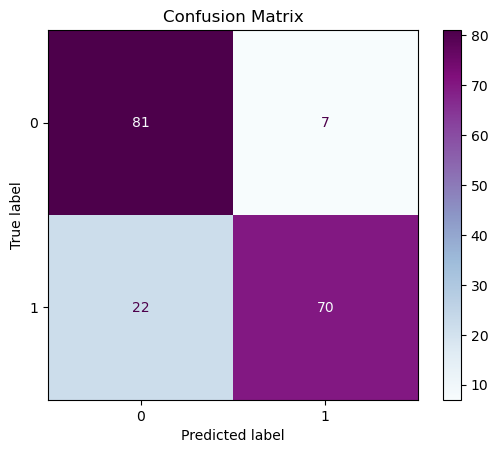

In [20]:
ConfusionMatrixDisplay.from_predictions(y_test, y_pred, cmap="BuPu")
plt.title("Confusion Matrix")
plt.show()